In [1]:
import os
os.listdir('../data/')

['MM-dataset description.pdf', '7wpcv7kp6f-1.zip', 'MM-DataSet.arff']

In [2]:
import pandas as pd
from scipy.io import arff
import io

# Leer el archivo como texto y limpiar espacios
with open('../data/MM-DataSet.arff', 'r') as f:
    content = f.read()

# Cargar con arff
data, meta = arff.loadarff(io.StringIO(content.replace(' ,', ',').replace(', ', ',').strip()))

# Convertir a DataFrame
df = pd.DataFrame(data)

# Decodificar columnas de texto (ARFF las carga como bytes)
str_cols = df.select_dtypes(include=['object']).columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.decode('utf-8').str.strip())

print(df.shape)
df.head()

(203, 59)


,wilaya,gender,age,body_surf,weight,married,nbrs_child,blood,HBP,diabete,...,HIV,Ag_HBS,gly,TCA,TP,Fib,Ferr,LDH,FE,CLASS
0,Tlemcen,0,74.0,1.76,68.0,1,8.0,?,0,0,...,?,?,1.09,NaN,NaN,NaN,NaN,201.0,69.0,6
1,Tlemcen,1,67.0,1.63,59.0,1,6.0,O+,0,0,...,0,0,0.96,34.1,77.3,2.71,NaN,327.0,65.0,6
2,Tlemcen,1,88.0,1.47,50.0,1,9.0,O+,1,0,...,0,0,0.73,NaN,NaN,NaN,NaN,349.5,NaN,6
3,SidiBelabes,1,63.0,NaN,65.0,?,NaN,O+,1,1,...,0,0,1.07,33.2,100.0,4.20,346.9,441.6,60.0,6
4,Tlemcen,0,53.0,NaN,NaN,1,5.0,A+,0,0,...,0,0,1.18,13.0,100.0,5.84,NaN,209.0,74.0,4


In [3]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== TARGET DISTRIBUTION ===")
print(df['CLASS'].value_counts())

=== SHAPE ===
(203, 59)

=== DATA TYPES ===
wilaya            object
gender            object
age              float64
body_surf        float64
weight           float64
married           object
nbrs_child       float64
blood             object
HBP               object
diabete           object
tobacco           object
chron_disea       object
hrd_blo_disea     object
asth&bone         object
anemia            object
CBC_WBC          float64
CBC_RBC          float64
CBC_plats        float64
CBC_Hgb          float64
CBC_Hct          float64
CBC_MCV          float64
CBC_MCHC         float64
VS               float64
roll_RBC          object
plasma_cells     float64
Ca               float64
K                float64
P                float64
Na               float64
B2M              float64
CRP               object
creat            float64
Urea             float64
clair_creat      float64
24h_prot          object
BJp               object
alb              float64
a_glob           float64
B_glob

In [4]:
# Official class mapping based on dataset documentation (Guilal et al., University of Tlemcen)
# Durie-Salmon Classification + International Staging System
class_mapping = {
    '0': 'MGUS',    # Monoclonal gammopathy of undetermined significance
    '1': 'ASYM',    # Asymptomatic Myeloma (Smoldering)
    '2': 'IA',      # Stage I type A (creatinine < 20 mg/l)
    '3': 'IB',      # Stage I type B (creatinine > 20 mg/l)
    '4': 'IIA',     # Stage II type A
    '5': 'IIB',     # Stage II type B
    '6': 'IIIA',    # Stage III type A — majority class
    '7': 'IIIB',    # Stage III type B
    '8': 'PLASMO'   # Plasmacytoma
}

df['CLASS_LABEL'] = df['CLASS'].map(class_mapping)

print("=== CLASS DISTRIBUTION ===\n")
for label, count in df['CLASS_LABEL'].value_counts().items():
    pct = count/len(df)*100
    print(f"  {label:8} → {count:3} patients ({pct:.1f}%)")

print(f"\n⚠️  Highly imbalanced dataset: IIIA accounts for {df[df['CLASS_LABEL']=='IIIA'].shape[0]/len(df)*100:.1f}% of total samples")

=== CLASS DISTRIBUTION ===

  IIIA     → 108 patients (53.2%)
  IIIB     →  37 patients (18.2%)
  IA       →  22 patients (10.8%)
  IIA      →  19 patients (9.4%)
  MGUS     →   6 patients (3.0%)
  ASYM     →   5 patients (2.5%)
  IB       →   3 patients (1.5%)
  PLASMO   →   2 patients (1.0%)
  IIB      →   1 patients (0.5%)

⚠️  Highly imbalanced dataset: IIIA accounts for 53.2% of total samples


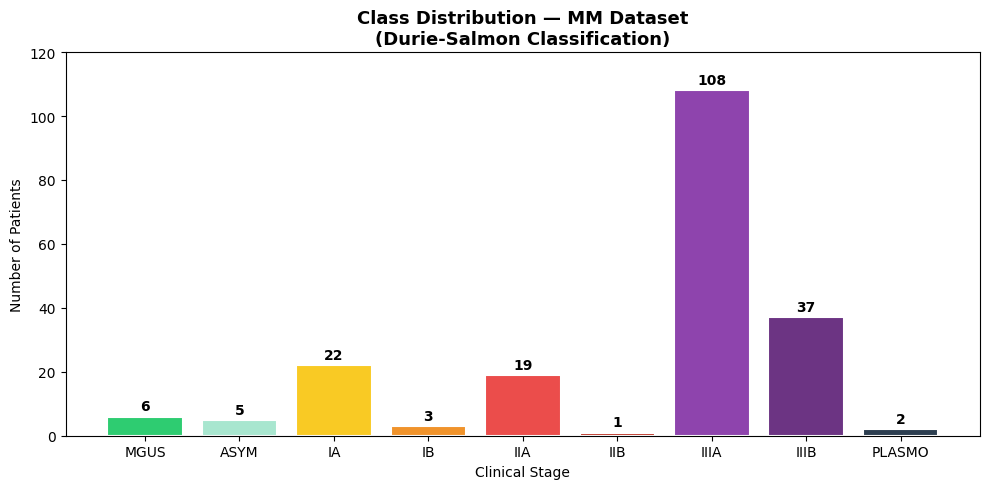

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colors by clinical severity
colors = {
    'MGUS': '#2ecc71',    # green - precancerous
    'ASYM': '#a8e6cf',    # light green - asymptomatic
    'IA':   '#f9ca24',    # yellow - stage I
    'IB':   '#f0932b',    # orange
    'IIA':  '#eb4d4b',    # light red - stage II
    'IIB':  '#c0392b',    # red
    'IIIA': '#8e44ad',    # purple - stage III
    'IIIB': '#6c3483',    # dark purple
    'PLASMO': '#2c3e50'   # dark - plasmacytoma
}

order = ['MGUS','ASYM','IA','IB','IIA','IIB','IIIA','IIIB','PLASMO']
counts = [df[df['CLASS_LABEL']==c].shape[0] for c in order]
bar_colors = [colors[c] for c in order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(order, counts, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontweight='bold')

ax.set_title('Class Distribution — MM Dataset\n(Durie-Salmon Classification)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Clinical Stage')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, 120)
plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', dpi=150)
plt.show()

In [6]:
# Concordance between Multiple Myeloma classification systems
concordance = {
    'Durie-Salmon Classification': ['MGUS', 'ASYM (SMM)', 'IA', 'IB', 'IIA', 'IIB', 'IIIA', 'IIIB', 'PLASMO'],
    'Clinical Progression':        ['MGUS', 'SMM', 'Active MM', 'Active MM', 'Active MM', 'Active MM', 'Active MM', 'Active MM', 'Active MM'],
    'Modeling Group':              ['Excluded*', 'Excluded*', 'Stage I', 'Stage I', 'Stage II', 'Stage II', 'Stage III', 'Stage III', 'Excluded*'],
    'N patients':                  [6, 5, 22, 3, 19, 1, 108, 37, 2]
}

df_concordance = pd.DataFrame(concordance)
print("=== CONCORDANCE BETWEEN CLASSIFICATION SYSTEMS ===\n")
print(df_concordance.to_string(index=False))
print("\n* Excluded from main modeling due to insufficient sample size")
print(f"  Patients included in modeling: {22+3+19+1+108+37} / {len(df)}")
print(f"  Patients excluded: {6+5+2} / {len(df)}")


=== CONCORDANCE BETWEEN CLASSIFICATION SYSTEMS ===

Durie-Salmon Classification Clinical Progression Modeling Group  N patients
                       MGUS                 MGUS      Excluded*           6
                 ASYM (SMM)                  SMM      Excluded*           5
                         IA            Active MM        Stage I          22
                         IB            Active MM        Stage I           3
                        IIA            Active MM       Stage II          19
                        IIB            Active MM       Stage II           1
                       IIIA            Active MM      Stage III         108
                       IIIB            Active MM      Stage III          37
                     PLASMO            Active MM      Excluded*           2

* Excluded from main modeling due to insufficient sample size
  Patients included in modeling: 190 / 203
  Patients excluded: 13 / 203


/tmp/ipykernel_9046/338505657.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9046/338505657.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(x_labels)
/tmp/ipykernel_9046/338505657.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9046/338505657.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(x_labels)
/tmp/ipykernel_9046/338505657.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

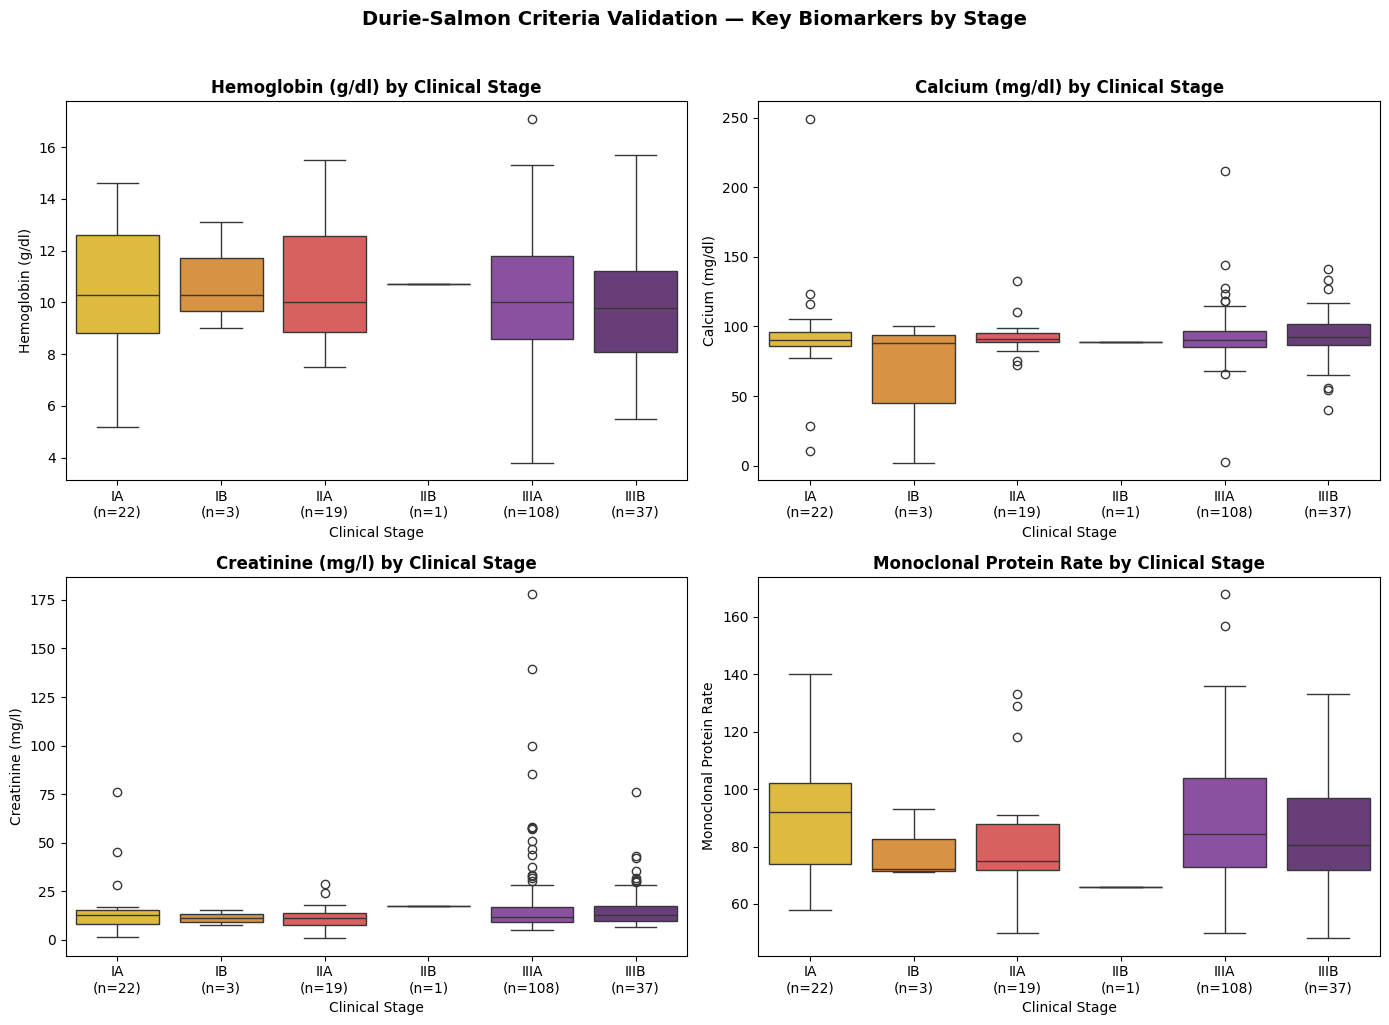

In [9]:
# =============================================================================
# DURIE-SALMON CRITERIA VALIDATION
# =============================================================================
# The Durie-Salmon staging system classifies Multiple Myeloma into 3 stages
# based on the following clinical criteria:
#
# Stage I (low tumor burden):
#   - Hemoglobin > 10 g/dl
#   - Normal calcium levels
#   - Normal bone X-ray or single lytic lesion
#   - Low monoclonal protein levels
#
# Stage III (high tumor burden):
#   - Hemoglobin < 8.5 g/dl
#   - Calcium > 12 mg/dl
#   - Multiple lytic bone lesions
#   - High monoclonal protein levels
#
# Sub-classification A/B based on kidney function:
#   - A: creatinine < 20 mg/l (normal kidney function)
#   - B: creatinine > 20 mg/l (kidney failure)
#
# Stage II: neither Stage I nor Stage III criteria
#
# Here we validate whether the dataset features are clinically coherent
# with the staging criteria by comparing key biomarkers across stages.
# =============================================================================

import seaborn as sns

# Filter only modeled stages (exclude MGUS, ASYM, PLASMO)
df_model = df[df['CLASS_LABEL'].isin(['IA', 'IB', 'IIA', 'IIB', 'IIIA', 'IIIB'])].copy()

# Key biomarkers according to Durie-Salmon criteria
biomarkers = {
    'CBC_Hgb': 'Hemoglobin (g/dl)',
    'Ca': 'Calcium (mg/dl)',
    'creat': 'Creatinine (mg/l)',
    'prot_rate': 'Monoclonal Protein Rate'
}

stage_order = ['IA', 'IB', 'IIA', 'IIB', 'IIIA', 'IIIB']
palette = ['#f9ca24', '#f0932b', '#eb4d4b', '#c0392b', '#8e44ad', '#6c3483']

# Sample counts per stage
stage_counts = df_model['CLASS_LABEL'].value_counts()
x_labels = [f'{s}\n(n={stage_counts.get(s, 0)})' for s in stage_order]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, label) in enumerate(biomarkers.items()):
    sns.boxplot(
        data=df_model,
        x='CLASS_LABEL', y=col,
        order=stage_order,
        palette=palette,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{label} by Clinical Stage', fontweight='bold')
    axes[idx].set_xlabel('Clinical Stage')
    axes[idx].set_ylabel(label)
    axes[idx].set_xticklabels(x_labels)

plt.suptitle('Durie-Salmon Criteria Validation — Key Biomarkers by Stage',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/durie_salmon_validation.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# =============================================================================
# DATA QUALITY NOTE: Calcium (Ca) units discrepancy
# =============================================================================
# The dataset documentation states Ca is expressed in mg/dl with range [10.3, 211.74].
# However, physiological analysis reveals inconsistencies:
#
# If values are in mg/dl:
#   - Min value 10.3 mg/dl → plausible (low end of normal)
#   - Median ~90 mg/dl → incompatible with life ❌
#
# If values are in mg/l:
#   - Min value 10.3 mg/l → 1.03 mg/dl → incompatible with life ❌
#   - Median ~90 mg/l → 9 mg/dl → normal range ✅
#
# Conclusion: the column likely contains a mix of units or transcription errors.
# The minimum value (10.3) is likely an outlier or data entry error.
# This column requires careful handling during preprocessing.
# We will flag extreme values as potential outliers before modeling.
# =============================================================================
print(f"Calcium stats:\n{df['Ca'].describe()}")

Calcium stats:
count    194.000000
mean      91.226546
std       23.629440
min        2.100000
25%       84.550000
50%       90.000000
75%       97.875000
max      249.280000
Name: Ca, dtype: float64


In [11]:
# =============================================================================
# EXTREME CALCIUM VALUES INVESTIGATION
# =============================================================================
# Investigating whether extreme calcium values correlate with advanced disease
# stage and other clinically related biomarkers.
# In advanced MM, bone destruction releases calcium into the bloodstream,
# which may also correlate with high creatinine (kidney stress),
# low hemoglobin (anemia) and high protein levels.
# =============================================================================

# Define threshold for extreme calcium (top 5%)
ca_threshold = df['Ca'].quantile(0.95)
print(f"Extreme calcium threshold (95th percentile): {ca_threshold:.1f}")

# Patients with extreme calcium
df_extreme_ca = df[df['Ca'] > ca_threshold]
df_normal_ca = df[df['Ca'] <= ca_threshold]

print(f"\nPatients with extreme calcium (>{ca_threshold:.1f}): {len(df_extreme_ca)}")
print(f"Patients with normal calcium: {len(df_normal_ca)}")

# Stage distribution in extreme calcium patients
print("\n=== STAGE DISTRIBUTION — EXTREME CALCIUM PATIENTS ===")
print(df_extreme_ca['CLASS_LABEL'].value_counts())

# Compare key biomarkers between extreme and normal calcium groups
print("\n=== KEY BIOMARKERS — EXTREME vs NORMAL CALCIUM ===")
biomarkers_check = ['CBC_Hgb', 'creat', 'prot_rate', 'B2M', 'plasma_cells']
comparison = pd.DataFrame({
    'Extreme Ca (mean)': df_extreme_ca[biomarkers_check].mean().round(2),
    'Normal Ca (mean)': df_normal_ca[biomarkers_check].mean().round(2)
})
print(comparison)

Extreme calcium threshold (95th percentile): 119.7

Patients with extreme calcium (>119.7): 10
Patients with normal calcium: 184

=== STAGE DISTRIBUTION — EXTREME CALCIUM PATIENTS ===
CLASS_LABEL
IIIA    4
IIIB    3
IA      2
IIA     1
Name: count, dtype: int64

=== KEY BIOMARKERS — EXTREME vs NORMAL CALCIUM ===
              Extreme Ca (mean)  Normal Ca (mean)
CBC_Hgb                    9.73             10.21
creat                     28.98             17.42
prot_rate                 90.37             88.10
B2M                       15.68              6.42
plasma_cells              25.02             26.81


In [12]:
# =============================================================================
# FINDINGS: EXTREME CALCIUM INVESTIGATION
# =============================================================================
# Patients with extreme calcium values (>119.7) show:
#
# - Creatinine: significantly higher (28.98 vs 17.42) → greater kidney damage
# - B2M (Beta-2 Microglobulin): nearly 3x higher (15.68 vs 6.42) → strongest
#   indicator of advanced disease and high tumor burden
# - Hemoglobin: slightly lower (9.73 vs 10.21) → consistent with more anemia
# - Monoclonal protein rate: similar in both groups → not discriminative
#
# Stage distribution: 7/10 extreme calcium patients are Stage III (expected),
# but 3 patients in early stages (IA, IIA) show extreme calcium —
# possible data entry errors or atypical clinical presentations.
#
# Key insight: B2M is the most discriminative biomarker between extreme
# and normal calcium groups, consistent with its role as a prognostic
# marker in the International Staging System (ISS).
# =============================================================================
print("Findings documented.")

Findings documented.


In [13]:
# =============================================================================
# MISSING VALUES ANALYSIS
# =============================================================================
# Identifying missing values across all features to inform preprocessing strategy.
# In clinical datasets, missing values are common and may not be random —
# a missing test result can itself be clinically meaningful.
# =============================================================================

# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

df_missing = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
df_missing_only = df_missing[df_missing['Missing Count'] > 0]

print(f"Total features: {len(df.columns)}")
print(f"Features with missing values: {len(df_missing_only)}")
print(f"Total missing values: {missing.sum()}")
print(f"\n{df_missing_only.to_string()}")

Total features: 60
Features with missing values: 36
Total missing values: 1480

              Missing Count  Missing %
Ferr                    169       83.3
B2M                     147       72.4
P                       129       63.5
Fib                     113       55.7
GGT                     100       49.3
TCA                      81       39.9
Na                       73       36.0
K                        73       36.0
nbrs_child               71       35.0
FE                       69       34.0
LDH                      65       32.0
PAL                      64       31.5
body_surf                55       27.1
TP                       49       24.1
weight                   39       19.2
plasma_cells             30       14.8
gly                      26       12.8
SGPT                     21       10.3
SGOT                     20        9.9
VS                       12        5.9
prot_rate                 9        4.4
Ca                        9        4.4
a_glob                 

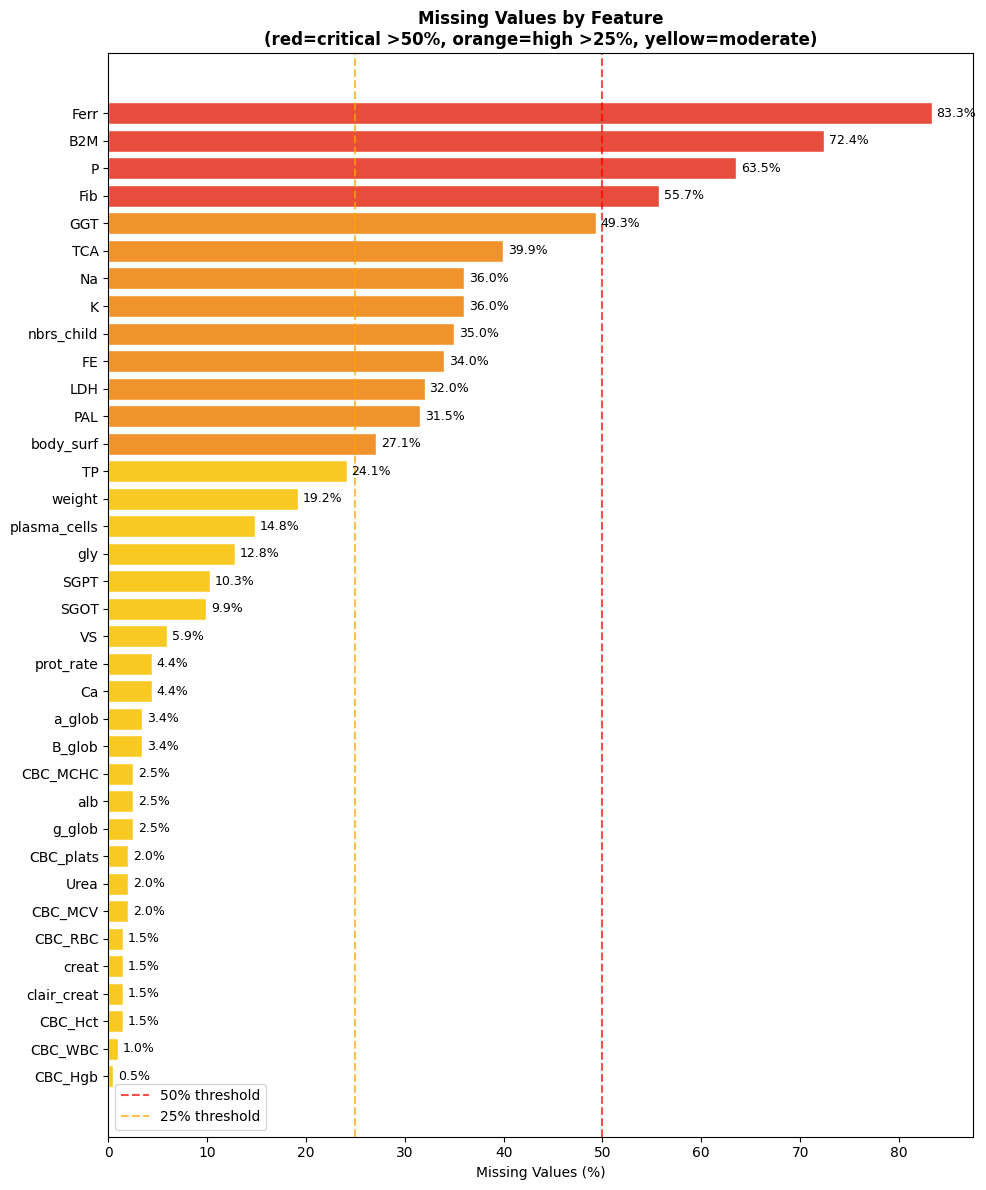

=== MISSING VALUES SEVERITY ===
Critical (>50%): 4 features → ['Ferr', 'B2M', 'P', 'Fib']
High (25-50%):   9 features
Moderate (<25%): 23 features


In [14]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 12))

colors = ['#e74c3c' if pct > 50 else '#f0932b' if pct > 25 else '#f9ca24' 
          for pct in df_missing_only['Missing %']]

bars = ax.barh(df_missing_only.index, df_missing_only['Missing %'], 
               color=colors, edgecolor='white')

# Add percentage labels
for bar, pct in zip(bars, df_missing_only['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

# Threshold lines
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.axvline(x=25, color='orange', linestyle='--', alpha=0.7, label='25% threshold')

ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Values by Feature\n(red=critical >50%, orange=high >25%, yellow=moderate)',
             fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../notebooks/missing_values.png', dpi=150)
plt.show()

# Summary by severity
print("=== MISSING VALUES SEVERITY ===")
print(f"Critical (>50%): {len(df_missing_only[df_missing_only['Missing %'] > 50])} features → {list(df_missing_only[df_missing_only['Missing %'] > 50].index)}")
print(f"High (25-50%):   {len(df_missing_only[(df_missing_only['Missing %'] > 25) & (df_missing_only['Missing %'] <= 50)])} features")
print(f"Moderate (<25%): {len(df_missing_only[df_missing_only['Missing %'] <= 25])} features")

In [ ]:
# =============================================================================
# MISSING VALUES HANDLING STRATEGY
# =============================================================================
# Strategy based on missing percentage thresholds:
#
# 1. Critical features (>50% missing): DROP the feature but CREATE a binary
#    indicator variable to preserve the clinical information that the test
#    was not performed (may itself be clinically meaningful).
#
# 2. High missing (25-50%): Impute with median (robust to outliers)
#
# 3. Moderate missing (<25%): Impute with median
#
# Note: B2M was identified as a key discriminative biomarker, so we preserve
# its availability information via a binary indicator before dropping it.
# =============================================================================

from sklearn.impute import SimpleImputer

# Define thresholds
CRITICAL_THRESHOLD = 50
df_processed = df.copy()

# --- Step 1: Create binary indicators for critical features ---
critical_features = list(df_missing_only[df_missing_only['Missing %'] > CRITICAL_THRESHOLD].index)
print(f"Critical features (>50% missing): {critical_features}")

for feat in critical_features:
    df_processed[f'{feat}_available'] = df_processed[feat].notna().astype(int)
    print(f"  Created indicator: {feat}_available")

# --- Step 2: Drop critical features ---
df_processed.drop(columns=critical_features, inplace=True)
print(f"\nDropped {len(critical_features)} critical features")

# --- Step 3: Impute remaining numeric missing values with median ---
numeric_cols = df_processed.select_dtypes(include='number').columns
imputer = SimpleImputer(strategy='median')
df_processed[numeric_cols] = imputer.fit_transform(df_processed[numeric_cols])

print(f"\nImputed remaining numeric missing values with median")
print(f"\n=== RESULT ===")
print(f"Original shape:  {df.shape}")
print(f"Processed shape: {df_processed.shape}")
print(f"Remaining missing values: {df_processed.isnull().sum().sum()}")

Critical features (>50% missing): ['Ferr', 'B2M', 'P', 'Fib']
  Created indicator: Ferr_available
  Created indicator: B2M_available
  Created indicator: P_available
  Created indicator: Fib_available

Dropped 4 critical features

Imputed remaining numeric missing values with median

=== RESULT ===
Original shape:  (203, 60)
Processed shape: (203, 60)
Remaining missing values: 0
